# Сравнение графов iduedu vs OSMnx

Визуализация дорожных графов: синий — iduedu, оранжевый — OSMnx.

In [1]:
import sys
from pathlib import Path

ROOT = Path(".").resolve()
if ROOT.name == "bridge":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# arctic_access scripts path
ARCTIC_PATH = ROOT / "arctic_access"
if str(ARCTIC_PATH) not in sys.path:
    sys.path.insert(0, str(ARCTIC_PATH))

import geopandas as gpd
import pandas as pd

## 1. Загрузка блоков (кварталов)

Используем данные arctic_access: берём 3 ближайших поселения к центроиду — маленький кусок для быстрой загрузки OSM.

In [2]:
from scripts.preprocesser.preprocesser import get_data
from scripts.calculator.calculator_this_pipeline import make_block_scheme
from scripts.preprocesser.constants import (
    transport_mode_name_mapper,
    transport_modes,
    MERCATOR_CRS,
)

DATA_PATH = str(ROOT / "arctic_access" / "data") + "/"
SETTL_NAME = "mezen"
SERVICE_NAME = "health"

settl, df_service, _, _ = get_data(
    DATA_PATH,
    SETTL_NAME,
    transport_mode_name_mapper,
    transport_modes,
    SERVICE_NAME,
)

# Маленький кусок: 3 ближайших поселения к центроиду (быстрый OSM)
centroid = settl.geometry.union_all().centroid
settl["_dist"] = settl.geometry.centroid.distance(centroid)
settl_sub = settl[settl["_dist"] < 100_000].drop(columns=["_dist"])
blocks_gdf = make_block_scheme(settl_sub, df_service, service_name=SERVICE_NAME)
boundary = settl_sub.geometry.union_all()
boundary_wgs84 = gpd.GeoSeries([boundary], crs=settl.crs).to_crs(4326).iloc[0]

print(f"Блоков: {len(blocks_gdf)}")

Блоков: 24


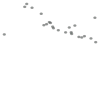

In [3]:
boundary_wgs84

## 2. Drive-граф (iduedu или OSMnx)

In [4]:
import osmnx as ox
from bridge import ensure_graph_has_time_min

# Буфер в метрах (как в iduedu) — расширяет полигон, чтобы захватить дороги между поселениями
OSM_BUFFER_M = 500

# Фильтр как в iduedu: motorway, trunk, primary, secondary, tertiary, unclassified,
# residential, living_street, service, pedestrian (+ _link). OSMnx drive по умолчанию
# исключает service и pedestrian — добавляем custom_filter.
OSM_CUSTOM_FILTER = (
    '["highway"~"^(motorway|motorway_link|trunk|trunk_link|primary|primary_link|'
    'secondary|secondary_link|tertiary|tertiary_link|unclassified|residential|'
    'living_street|service|pedestrian)$"]["access"!~"^(private|permissive|no)$"]'
    '["service"!~"^(driveway|parking_aisle)$"]'
)

def _get_osm_graph(simplify: bool = True, buffer_m: float = OSM_BUFFER_M):
    poly = boundary_wgs84.convex_hull
    if buffer_m and buffer_m > 0:
        # Буфер в метрах: проецируем в metric CRS, буфер, обратно в WGS84
        gs = gpd.GeoSeries([poly], crs=4326).to_crs(3857)
        poly = gpd.GeoSeries([gs.iloc[0].buffer(buffer_m)], crs=3857).to_crs(4326).iloc[0]
    try:
        G = ox.graph_from_polygon(poly, network_type="drive", simplify=simplify, custom_filter=OSM_CUSTOM_FILTER)
    except (RuntimeError, IndexError):
        minx, miny, maxx, maxy = gpd.GeoSeries([poly], crs=4326).total_bounds
        bbox = (minx, miny, maxx, maxy)
        G = ox.graph_from_bbox(bbox=bbox, network_type="drive", simplify=simplify, custom_filter=OSM_CUSTOM_FILTER)
    return ensure_graph_has_time_min(G)

# iduedu (если доступен)
try:
    from iduedu import get_drive_graph
    G_drive_iduedu = get_drive_graph(territory=boundary_wgs84)
    use_iduedu = True
    print("G_drive_iduedu: узлов:", G_drive_iduedu.number_of_nodes(), ", рёбер:", G_drive_iduedu.number_of_edges())
except ImportError:
    G_drive_iduedu = None
    use_iduedu = False
    print("iduedu не установлен, пропускаем")

# OSMnx (convex_hull + буфер 500м)
G_drive_osm = _get_osm_graph(simplify=True)
print("G_drive_osm: узлов:", G_drive_osm.number_of_nodes(), ", рёбер:", G_drive_osm.number_of_edges())

# Для bridge/arctic пайплайна
G_drive = G_drive_iduedu if G_drive_iduedu is not None else G_drive_osm

2026-03-14 14:49:16.366 | INFO     | Downloading drive network via Overpass ...
2026-03-14 14:49:16.370 | INFO     | Downloading network via Overpass done!
2026-03-14 14:49:16.566 | WARNING  | Removing 16 nodes from 1 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (541 nodes).


G_drive_iduedu: узлов: 541 , рёбер: 1434
G_drive_osm: узлов: 716 , рёбер: 1984


## 3. Bridge: graph_to_arctic_format

In [5]:
from bridge import graph_to_arctic_format, settl_from_blocks

# arctic_compatible=True по умолчанию: колонки Aviation, Regular road, Winter road, Water transport
transport_df, G_arctic = graph_to_arctic_format(
    blocks_gdf,
    G_drive,
    service_name=SERVICE_NAME,
    use_iduedu=use_iduedu,
)

settl = settl_from_blocks(blocks_gdf)

print(f"transport_df: {len(transport_df)} рёбер")
print("Колонки:", list(transport_df.columns))
transport_df.head(10)

transport_df: 546 рёбер
Колонки: ['edge1', 'edge2', 'Regular road', 'Aviation', 'Winter road', 'Water transport']


,edge1,edge2,Regular road,Aviation,Winter road,Water transport
0,Bereznik,Bor,51.24,0.0,0.0,0.0
1,Bereznik,Bych'e,55.55,0.0,0.0,0.0
2,Bereznik,Dorogorskoe,37.78,0.0,0.0,0.0
3,Bereznik,Zherd',22.65,0.0,0.0,0.0
4,Bereznik,Zhukova,20.29,0.0,0.0,0.0
5,Bereznik,Zaakakur'e,51.03,0.0,0.0,0.0
6,Bereznik,Zaozer'e,43.06,0.0,0.0,0.0
7,Bereznik,Zaton,95.92,0.0,0.0,0.0
8,Bereznik,Kar'epol'e,395.91,0.0,0.0,0.0
9,Bereznik,Kil'tsa,48.92,0.0,0.0,0.0


## 4. make_g → Arctic граф

In [6]:
from scripts.preprocesser.gcreator import make_g
from scripts.preprocesser.constants import transport_modes

# transport_modes = ["Aviation", "Regular road", "Winter road", "Water transport"]
G_undirected = make_g(transport_df, transport_modes, blocks_gdf, settl)

print(f"G_undirected: {G_undirected.number_of_nodes()} узлов, {G_undirected.number_of_edges()} рёбер")

G_undirected: 24 узлов, 1092 рёбер


In [7]:
G_undirected.edges(data=True)

MultiEdgeDataView([('Bereznik', 'Bor', {'weight': 51.24, 'label': 'Regular road'}), ('Bereznik', 'Bor', {'weight': 51.24, 'label': 'Regular road'}), ('Bereznik', 'Bor', {'weight': 51.24, 'label': 'Regular road'}), ('Bereznik', 'Bor', {'weight': 51.24, 'label': 'Regular road'}), ('Bereznik', "Bych'e", {'weight': 55.55, 'label': 'Regular road'}), ('Bereznik', "Bych'e", {'weight': 55.55, 'label': 'Regular road'}), ('Bereznik', "Bych'e", {'weight': 55.55, 'label': 'Regular road'}), ('Bereznik', "Bych'e", {'weight': 55.55, 'label': 'Regular road'}), ('Bereznik', 'Dorogorskoe', {'weight': 37.78, 'label': 'Regular road'}), ('Bereznik', 'Dorogorskoe', {'weight': 37.78, 'label': 'Regular road'}), ('Bereznik', 'Dorogorskoe', {'weight': 37.78, 'label': 'Regular road'}), ('Bereznik', 'Dorogorskoe', {'weight': 37.78, 'label': 'Regular road'}), ('Bereznik', "Zherd'", {'weight': 22.65, 'label': 'Regular road'}), ('Bereznik', "Zherd'", {'weight': 22.65, 'label': 'Regular road'}), ('Bereznik', "Zherd'"

## 5. Расчёт провижена (Arctic)

In [8]:
from scripts.preprocesser.constants import CONST_BASE_DEMAND, service_radius_minutes
import scripts.model.provision as provision

radius = service_radius_minutes.get(SETTL_NAME, 60)

# Провижен для текущего графа (iduedu или OSM)
G_with_prov, prov_result, _ = provision.calculate_graph_provision(
    G_undirected,
    service_radius=radius,
    const_base_demand=CONST_BASE_DEMAND,
    service_name=SERVICE_NAME,
    return_assignment=True,
    method="lp",
)

# Сохраняем результат iduedu для сравнения
prov_result_iduedu = prov_result.copy() if use_iduedu else None

print("Провижен (текущий граф — iduedu)" if use_iduedu else "Провижен (текущий граф — OSM)")
print(prov_result.reset_index()[["name", "provision", "demand", f"capacity_{SERVICE_NAME}"]].to_string())

Провижен (текущий граф — iduedu)
               name  provision  demand  capacity_health
0          Bereznik        1.0    17.0            600.0
1               Bor        1.0    15.0              0.0
2            Bych'e        1.0    18.0            600.0
3       Dorogorskoe        1.0    42.0            600.0
4            Zherd'        1.0    13.0           1200.0
5           Zhukova        1.0    15.0              0.0
6        Zaakakur'e        1.0     9.0            600.0
7          Zaozer'e        1.0     4.0            600.0
8             Zaton        1.0    15.0              0.0
9        Kar'epol'e        1.0     8.0            600.0
10          Kil'tsa        1.0    10.0            600.0
11           Kimzha        1.0     9.0            600.0
12  Koz'mogorodskoe        1.0    10.0            600.0
13       Lampozhnja        1.0     9.0            600.0
14           Mezen'        1.0   340.0           1800.0
15        Morozilka        1.0    15.0              0.0
16          Pet

## 6. Сравнение iduedu vs OSM (провижен)

Запускаем полный пайплайн на OSM-графе и сравниваем результаты расчёта провижена.

### Сравнение adjacency-матриц (iduedu vs OSM)

Матрицы времени в минутах между кварталами.

In [9]:
import numpy as np
from bridge import blocks_adjacency_from_graph, graph_to_bridge_format

# Adj-матрицы для обоих графов (время в минутах)
G_iduedu_br = graph_to_bridge_format(G_drive_iduedu, source="iduedu") if G_drive_iduedu is not None else None
G_osm_br = graph_to_bridge_format(G_drive_osm, source="osmnx")

adj_iduedu = blocks_adjacency_from_graph(blocks_gdf, G_iduedu_br, use_iduedu=True) if G_iduedu_br is not None else None
adj_osm = blocks_adjacency_from_graph(blocks_gdf, G_osm_br, use_iduedu=False)

# Переименовать для читаемости (index -> name)
idx2name = dict(zip(blocks_gdf.index, blocks_gdf["name"]))

print("=== Adj iduedu (мин) ===")
if adj_iduedu is not None:
    adj_iduedu_display = adj_iduedu.rename(index=idx2name, columns=idx2name)
    display(adj_iduedu_display)
else:
    print("iduedu недоступен")

print("\n=== Adj OSM (мин) ===")
adj_osm_display = adj_osm.rename(index=idx2name, columns=idx2name)
display(adj_osm_display)

# Сравнение: где различаются
if adj_iduedu is not None:
    diff = adj_osm - adj_iduedu
    diff = diff.replace([np.inf, -np.inf], np.nan)
    diff_flat = diff.stack().dropna()
    diff_flat = diff_flat[diff_flat.abs() > 0.01]
    print(f"\n=== Отличия (|diff| > 0.01 мин): {len(diff_flat)} пар ===")
    if len(diff_flat) > 0:
        display(diff_flat.to_frame("diff_min").head(30))

=== Adj iduedu (мин) ===


,Bereznik,Bor,Bych'e,Dorogorskoe,Zherd',Zhukova,Zaakakur'e,Zaozer'e,Zaton,Kar'epol'e,...,Mezen',Morozilka,Petrova,Petrovka,Pechische,Pogorelets,Timoschel'e,Ust'-Njafta,Ust'-Peza,Chetsa
Bereznik,0.000000,51.237246,55.554624,37.782201,22.647184,20.292568,51.025992,43.064618,95.922095,395.912325,...,67.664908,89.951750,21.919017,146.685270,52.491149,8.905028,42.550506,37.586685,31.962513,171.262466
Bor,51.237246,0.000000,55.802812,18.080389,33.735372,39.090757,4.634181,10.592807,49.530283,398.960513,...,21.273097,43.559939,38.997206,100.293459,55.539338,58.713217,13.158694,37.834874,30.190702,124.870655
Bych'e,55.554624,55.802812,0.000000,42.347767,38.052750,43.408135,55.591558,47.630185,100.487661,403.277891,...,72.230474,94.517317,43.314583,151.250837,59.856715,63.030595,47.116072,33.252252,36.528080,175.828033
Dorogorskoe,37.782201,18.080389,42.347767,0.000000,20.280327,25.635712,17.869135,9.907761,62.765238,385.505468,...,34.508051,56.794894,25.542160,113.528414,42.084292,45.258171,9.393649,24.379829,16.735656,138.105610
Zherd',22.647184,33.735372,38.052750,20.280327,0.000000,6.960695,33.524119,25.562745,78.420221,378.410451,...,50.163034,72.449877,6.867143,129.183397,34.989275,30.123155,25.048632,20.084812,14.460640,153.760593
Zhukova,20.292568,39.090757,43.408135,25.635712,6.960695,0.000000,38.879503,30.918129,83.775606,383.765836,...,55.518419,77.805261,4.642528,134.538781,40.344660,27.768539,30.404017,25.440196,19.816024,159.115978
Zaakakur'e,51.025992,4.634181,55.591558,17.869135,33.524119,38.879503,0.000000,10.381553,46.819030,398.749260,...,18.561843,40.848685,38.785952,97.582205,55.328084,58.501963,12.947441,37.623620,29.979448,122.159401
Zaozer'e,43.064618,10.592807,47.630185,9.907761,25.562745,30.918129,10.381553,0.000000,55.277656,390.787886,...,27.020469,49.307311,30.824578,106.040831,47.366710,50.540589,4.986067,29.662246,22.018074,130.618027
Zaton,95.922095,49.530283,100.487661,62.765238,78.420221,83.775606,46.819030,55.277656,0.000000,441.015362,...,34.077945,49.484788,83.682054,106.218308,99.634186,103.398066,57.843543,82.519723,74.875551,130.795504
Kar'epol'e,395.912325,398.960513,403.277891,385.505468,378.410451,383.765836,398.749260,390.787886,441.015362,0.000000,...,415.388175,437.675018,383.672284,494.408538,389.574417,403.388296,390.273773,385.309953,379.685781,518.985734



=== Adj OSM (мин) ===


,Bereznik,Bor,Bych'e,Dorogorskoe,Zherd',Zhukova,Zaakakur'e,Zaozer'e,Zaton,Kar'epol'e,...,Mezen',Morozilka,Petrova,Petrovka,Pechische,Pogorelets,Timoschel'e,Ust'-Njafta,Ust'-Peza,Chetsa
Bereznik,0.000000,93.365456,108.234934,68.619226,40.545519,34.209010,96.042584,79.948582,163.109592,163.109592,...,128.828733,160.647040,35.346927,160.647040,91.624453,15.254699,77.387190,66.544542,58.091661,160.647040
Bor,93.365456,0.000000,101.891783,29.047776,56.836401,62.819815,2.677128,14.282590,73.873449,73.873449,...,35.463277,67.281584,61.681898,67.281584,90.852858,107.722073,19.569635,60.201392,47.714810,67.281584
Bych'e,108.234934,101.891783,0.000000,77.145554,71.705879,77.689293,104.568912,88.474909,175.765233,175.765233,...,137.355061,169.173367,76.551376,169.173367,105.722336,122.591550,85.913518,57.323235,66.617988,169.173367
Dorogorskoe,68.619226,29.047776,77.145554,0.000000,32.090171,38.073585,31.724905,15.630902,102.921226,102.921226,...,64.511053,96.329360,36.935668,96.329360,66.106628,82.975843,10.384627,35.455162,22.968580,96.329360
Zherd',40.545519,56.836401,71.705879,32.090171,0.000000,6.336509,59.513529,43.419527,126.580537,126.580537,...,92.299678,124.117985,5.198592,124.117985,55.095398,54.902136,40.858135,30.015487,21.562606,124.117985
Zhukova,34.209010,62.819815,77.689293,38.073585,6.336509,0.000000,65.496943,49.402941,132.563950,132.563950,...,98.283092,130.101399,1.137917,130.101399,61.078811,48.565627,46.841549,35.998901,27.546020,130.101399
Zaakakur'e,96.042584,2.677128,104.568912,31.724905,59.513529,65.496943,0.000000,16.959719,71.532934,71.532934,...,33.122762,64.941069,64.359027,64.941069,93.529987,110.399201,22.246764,62.878520,50.391938,64.941069
Zaozer'e,79.948582,14.282590,88.474909,15.630902,43.419527,49.402941,16.959719,0.000000,88.156040,88.156040,...,49.745867,81.564174,48.265024,81.564174,77.435984,94.305199,6.152761,46.784518,34.297936,81.564174
Zaton,163.109592,73.873449,175.765233,102.921226,126.580537,132.563950,71.532934,88.156040,0.000000,0.000000,...,45.947252,63.996077,131.426034,63.996077,131.970551,177.466208,93.443085,134.074841,121.588259,63.996077
Kar'epol'e,163.109592,73.873449,175.765233,102.921226,126.580537,132.563950,71.532934,88.156040,0.000000,0.000000,...,45.947252,63.996077,131.426034,63.996077,131.970551,177.466208,93.443085,134.074841,121.588259,63.996077



=== Отличия (|diff| > 0.01 мин): 546 пар ===


diff_min
0 1    42.128210
  2    52.680310
  3    30.837026
  4    17.898335
  5    13.916442
  6    45.016592
  7    36.883964
  8    67.187497
  9  -232.802733
  10   37.213926
  11   28.601523
  12    4.987131
  13   43.570365
  14   61.163825
  15   70.695290
  16   13.427910
  17   13.961770
  18   39.133304
  19    6.349671
  20   34.836685
  21   28.957857
  22   26.129148
  23  -10.615426
1 0    42.128210
  2    46.088971
  3    10.967387
  4    23.101029
  5    23.729058
  6    -1.957053
  7     3.689784

### Визуальное сравнение графов (iduedu vs OSM)

Оба графа на одной карте: синий — iduedu, оранжевый — OSM.

/var/folders/72/4xflf9vn3szd81nsycnp8hd40000gn/T/ipykernel_6387/1245584296.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left")


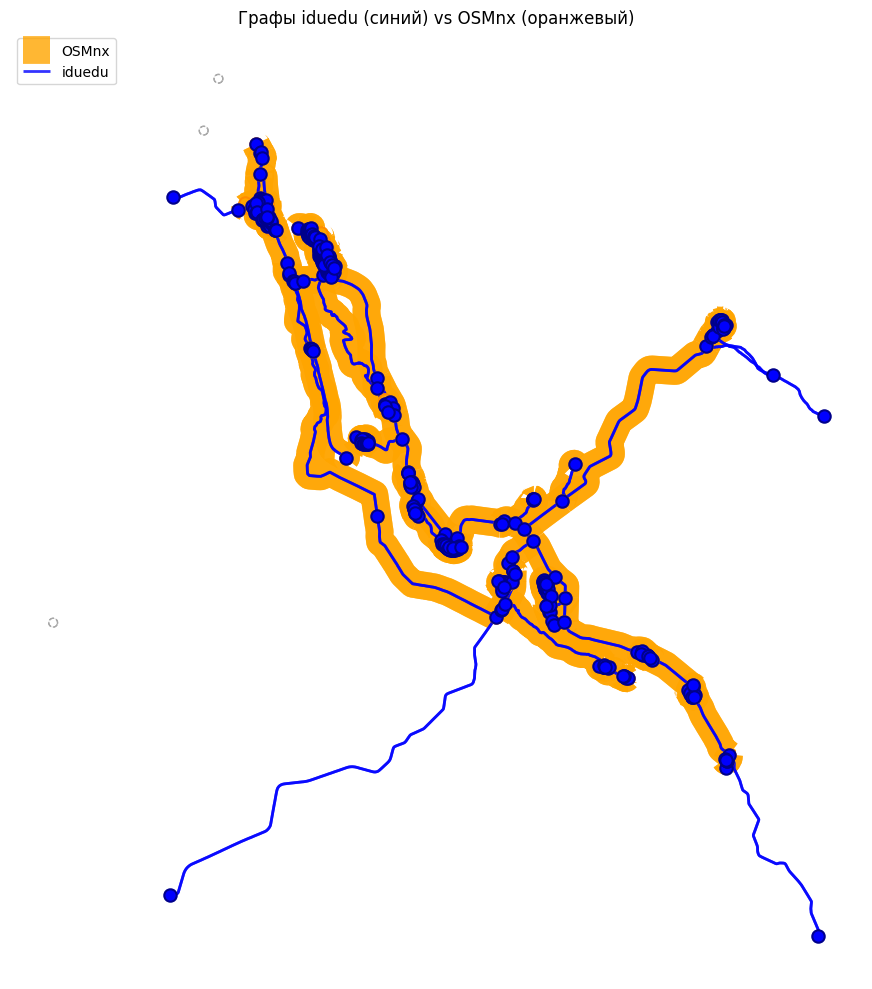

In [10]:
import matplotlib.pyplot as plt

# Графы в GeoDataFrame для визуализации
nodes_osm, edges_osm = ox.graph_to_gdfs(G_drive_osm, fill_edge_geometry=True)
edges_osm = edges_osm[edges_osm.geometry.notna()].copy()
if edges_osm.crs != 4326:
    edges_osm = edges_osm.to_crs(4326)
if nodes_osm.crs != 4326:
    nodes_osm = nodes_osm.to_crs(4326)

if G_drive_iduedu is not None:
    from iduedu import graph_to_gdf
    nodes_iduedu, _ = ox.graph_to_gdfs(G_drive_iduedu, fill_edge_geometry=True)
    edges_iduedu = graph_to_gdf(G_drive_iduedu, restore_edge_geom=True)
    edges_iduedu = edges_iduedu[edges_iduedu.geometry.notna()].copy()
    edges_iduedu = edges_iduedu[edges_iduedu.geometry.geom_type.isin(["LineString", "MultiLineString"])]
    edges_iduedu = edges_iduedu.explode(index_parts=False).reset_index(drop=True)
    if edges_iduedu.crs and str(edges_iduedu.crs) != "EPSG:4326":
        edges_iduedu = edges_iduedu.to_crs(4326)
    if nodes_iduedu.crs and str(nodes_iduedu.crs) != "EPSG:4326":
        nodes_iduedu = nodes_iduedu.to_crs(4326)

# Boundary и блоки в WGS84
boundary_gdf = gpd.GeoDataFrame({"geometry": [boundary_wgs84]}, crs=4326)
blocks_wgs84 = blocks_gdf.to_crs(4326)

# Рисуем
fig, ax = plt.subplots(figsize=(12, 10))
boundary_gdf.plot(ax=ax, facecolor="none", edgecolor="gray", linewidth=1, linestyle="--", label="boundary")
blocks_wgs84.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.5, alpha=0.7)

edges_osm.plot(ax=ax, color="orange", linewidth=20, alpha=0.8, label="OSMnx")

if G_drive_iduedu is not None:
    edges_iduedu.plot(ax=ax, color="blue", linewidth=2, alpha=0.8, label="iduedu")

# Ноды крупно
nodes_osm.plot(ax=ax, color="orange", markersize=80, marker="o", edgecolors="darkorange", linewidths=1.5, zorder=5)
if G_drive_iduedu is not None:
    nodes_iduedu.plot(ax=ax, color="blue", markersize=80, marker="o", edgecolors="darkblue", linewidths=1.5, zorder=5)

ax.legend(loc="upper left")
ax.set_axis_off()
ax.set_title("Графы iduedu (синий) vs OSMnx (оранжевый)")
plt.tight_layout()
plt.show()

In [11]:
# Пайплайн для OSM (bridge → make_g → provision)
transport_df_osm, _ = graph_to_arctic_format(
    blocks_gdf,
    G_drive_osm,
    service_name=SERVICE_NAME,
    use_iduedu=False,
)
settl_osm = settl_from_blocks(blocks_gdf)
G_undirected_osm = make_g(transport_df_osm, transport_modes, blocks_gdf, settl_osm)

_, prov_result_osm, _ = provision.calculate_graph_provision(
    G_undirected_osm,
    service_radius=radius,
    const_base_demand=CONST_BASE_DEMAND,
    service_name=SERVICE_NAME,
    return_assignment=True,
    method="lp",
)

# Сравнение провижена: iduedu vs OSM
if prov_result_iduedu is not None and G_drive_iduedu is not None:
    df_iduedu = prov_result_iduedu.reset_index()[["name", "provision", "demand", f"capacity_{SERVICE_NAME}"]]
    df_iduedu = df_iduedu.rename(columns={"provision": "provision_iduedu"})
    df_osm = prov_result_osm.reset_index()[["name", "provision"]]
    df_osm = df_osm.rename(columns={"provision": "provision_osm"})
    compare = df_iduedu[["name", "provision_iduedu"]].merge(
        df_osm[["name", "provision_osm"]], on="name", how="outer"
    )
    compare["diff"] = (compare["provision_osm"] - compare["provision_iduedu"]).round(4)
    print("Сравнение prov_result: iduedu vs OSM")
    print(compare.to_string())
    print("\nСводка: совпадают" if (compare["diff"].abs() < 1e-6).all() else "\nСводка: есть расхождения")
else:
    print("iduedu недоступен — показываем только OSM:")
    print(prov_result_osm.reset_index()[["name", "provision", "demand", f"capacity_{SERVICE_NAME}"]].to_string())

Сравнение prov_result: iduedu vs OSM
               name  provision_iduedu  provision_osm  diff
0          Bereznik               1.0            1.0   0.0
1               Bor               1.0            1.0   0.0
2            Bych'e               1.0            1.0   0.0
3            Chetsa               0.0            1.0   1.0
4       Dorogorskoe               1.0            1.0   0.0
5        Kar'epol'e               1.0            1.0   0.0
6           Kil'tsa               1.0            1.0   0.0
7            Kimzha               1.0            1.0   0.0
8   Koz'mogorodskoe               1.0            1.0   0.0
9        Lampozhnja               1.0            1.0   0.0
10           Mezen'               1.0            1.0   0.0
11        Morozilka               1.0            1.0   0.0
12        Pechische               1.0            1.0   0.0
13          Petrova               1.0            1.0   0.0
14         Petrovka               0.0            1.0   1.0
15       Pogorelets